## Data Cleaning & Augmentation
### MTSamples Medical Specialty Classification
This notebook handles:
- Data cleaning and filtering
- Text preprocessing (lowercasing, stopword removal, lemmatization)
- Back-translation based data augmentation
- Removal of document-type specialties
- Final dataset export

In [1]:
# Install required dependencies
# pip install kagglehub

SyntaxError: invalid syntax (4187167578.py, line 2)

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "mtsamples.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "tboyle10/medicaltranscriptions",
  file_path
)

print("First 5 records:", df.head())

/tmp/ipykernel_729/2361693870.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 4.85M/4.85M [00:00<00:00, 80.7MB/s]

Extracting zip of mtsamples.csv...


First 5 records:    Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   

In [3]:
# First 5 records
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [4]:
# Drop auto-generated index column from CSV
df = df.drop(columns=['Unnamed: 0'])

In [5]:
# First 5 records after removing unnamed column
df.head()

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [17]:
import pandas as pd

medical_specialty_list = df['medical_specialty'].unique()
data_count_list =[]

for medical_specialty in medical_specialty_list:
    df_filter = df.loc[(df['medical_specialty'] == medical_specialty)]
    data_count_list.append(len(df_filter))

data_count_df = pd.DataFrame({'Medical Specialty':medical_specialty_list, 'Data Count':data_count_list})
data_count_df['Data Count'] = data_count_df['Data Count'].astype('int')
data_count_df = data_count_df.sort_values('Data Count', ascending=False)
data_count_df.reset_index(drop=True)

,Medical Specialty,Data Count
0,Surgery,1103
1,Consult - History and Phy.,516
2,Cardiovascular / Pulmonary,372
3,Orthopedic,355
4,Radiology,273
5,General Medicine,259
6,Gastroenterology,230
7,Neurology,223
8,SOAP / Chart / Progress Notes,166
9,Obstetrics / Gynecology,160


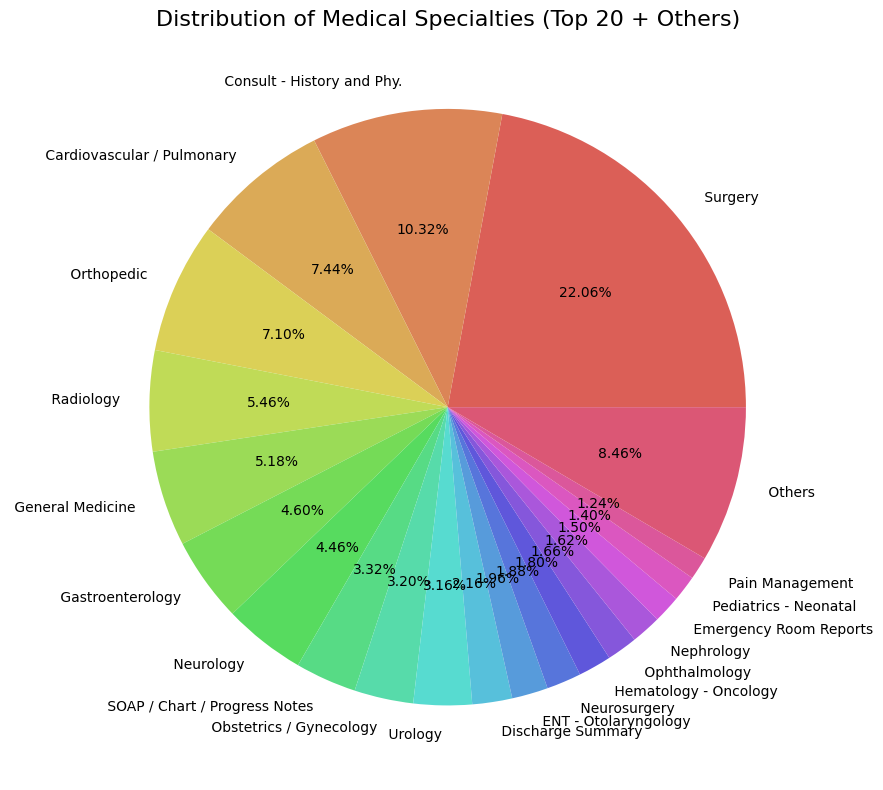

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df_top_n = data_count_df.head(20).copy()

other_count = data_count_df.iloc[20:]['Data Count'].sum()

df_others = pd.DataFrame(
    [{'Medical Specialty': ' Others', 'Data Count': other_count}]
)

df_combined = pd.concat([df_top_n, df_others], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette('hls', n_colors=len(df_combined))

ax.pie(df_combined['Data Count'], colors=colors, labels=df_combined['Medical Specialty'], autopct='%1.2f%%')

ax.set_title(f'Distribution of Medical Specialties (Top 20 + Others)', fontsize=16)

plt.tight_layout()

plt.show()

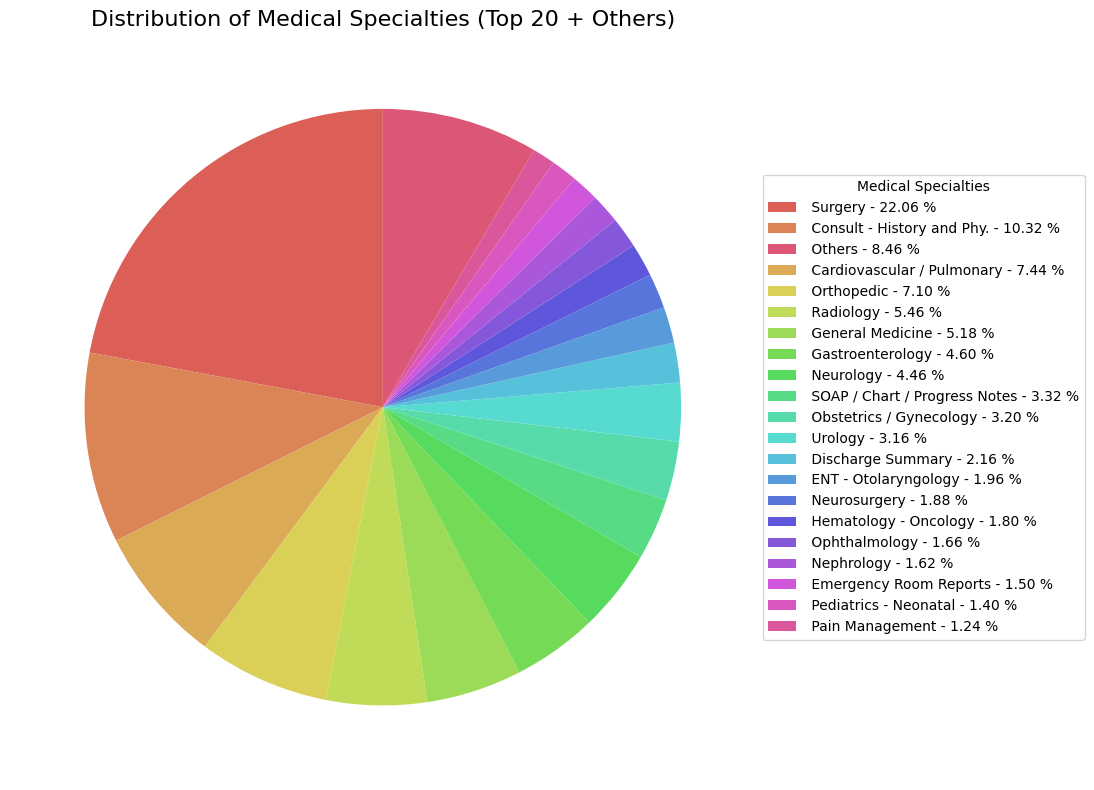

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

df_top_n = data_count_df.head(20).copy()

other_count = data_count_df.iloc[20:]['Data Count'].sum()

df_others = pd.DataFrame(
    [{'Medical Specialty': ' Others', 'Data Count': other_count}]
)

df_combined = pd.concat([df_top_n, df_others], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette('hls', n_colors=len(df_combined))

# Generate the pie chart without autopct to keep it clean
wedges, texts = ax.pie(df_combined['Data Count'], colors=colors, startangle=90)

# Calculate percentages based on df_combined
percent = 100 * df_combined['Data Count'] / df_combined['Data Count'].sum()

# Create custom labels for the legend, combining specialty name and percentage
labels_for_legend = ['{0} - {1:1.2f} %'.format(name, pct) for name, pct in zip(df_combined['Medical Specialty'], percent)]

sort_legend = True
if sort_legend:
    # Sort wedges and labels together based on Data Count in descending order
    sorted_items = sorted(zip(wedges, labels_for_legend, df_combined['Data Count']),
                          key=lambda x: x[2], reverse=True)
    wedges, labels_for_legend, _ = zip(*sorted_items)

# Add a legend to the right of the pie chart
ax.legend(wedges, labels_for_legend, title="Medical Specialties", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

ax.set_title(f'Distribution of Medical Specialties (Top 20 + Others)', fontsize=16)

plt.tight_layout()
plt.show()


/tmp/ipykernel_729/2411671326.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top20['Percentage'] = (top20['Data Count'] / total_count) * 100


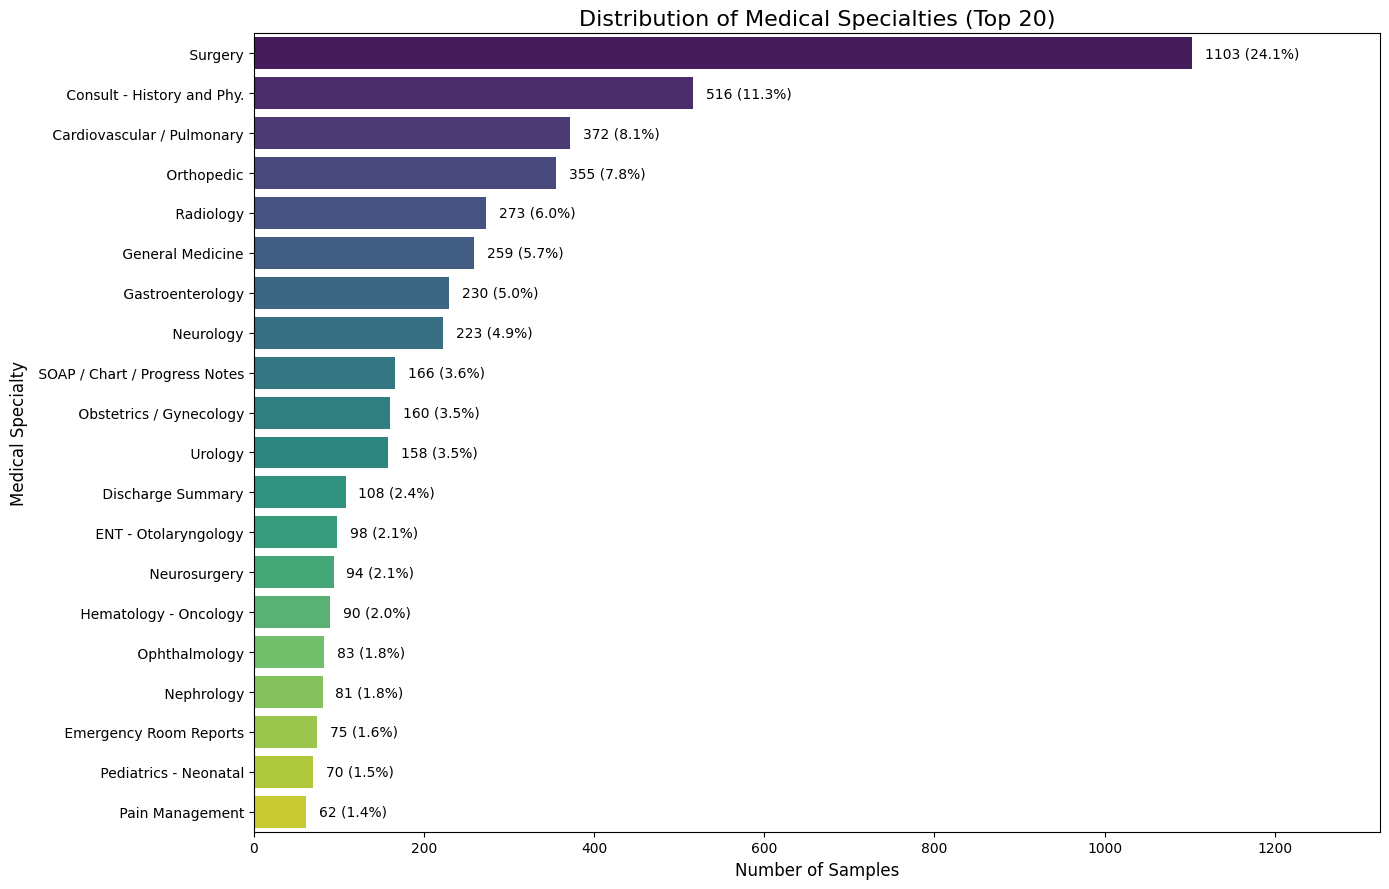

In [23]:
fig, ax = plt.subplots(figsize=(14, 9))
top20 = data_count_df.head(20).copy() # Ensure top20 is a copy

sns.barplot(x='Data Count', y='Medical Specialty', data=top20,
            palette='viridis', hue='Medical Specialty', legend=False, ax=ax)

ax.set_title('Distribution of Medical Specialties (Top 20)', fontsize=16)
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_ylabel('Medical Specialty', fontsize=12)

# Calculate percentages
total_count = top20['Data Count'].sum()
top20['Percentage'] = (top20['Data Count'] / total_count) * 100

# Use enumerate to get proper bar positions (0, 1, 2, ...)
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['Data Count'] + 15, i, f"{row['Data Count']} ({row['Percentage']:.1f}%)",
            va='center', fontsize=10)

# Adjust x-axis limits to prevent labels from being cut off
ax.set_xlim(right=top20['Data Count'].max() * 1.2)

plt.tight_layout()
plt.show()


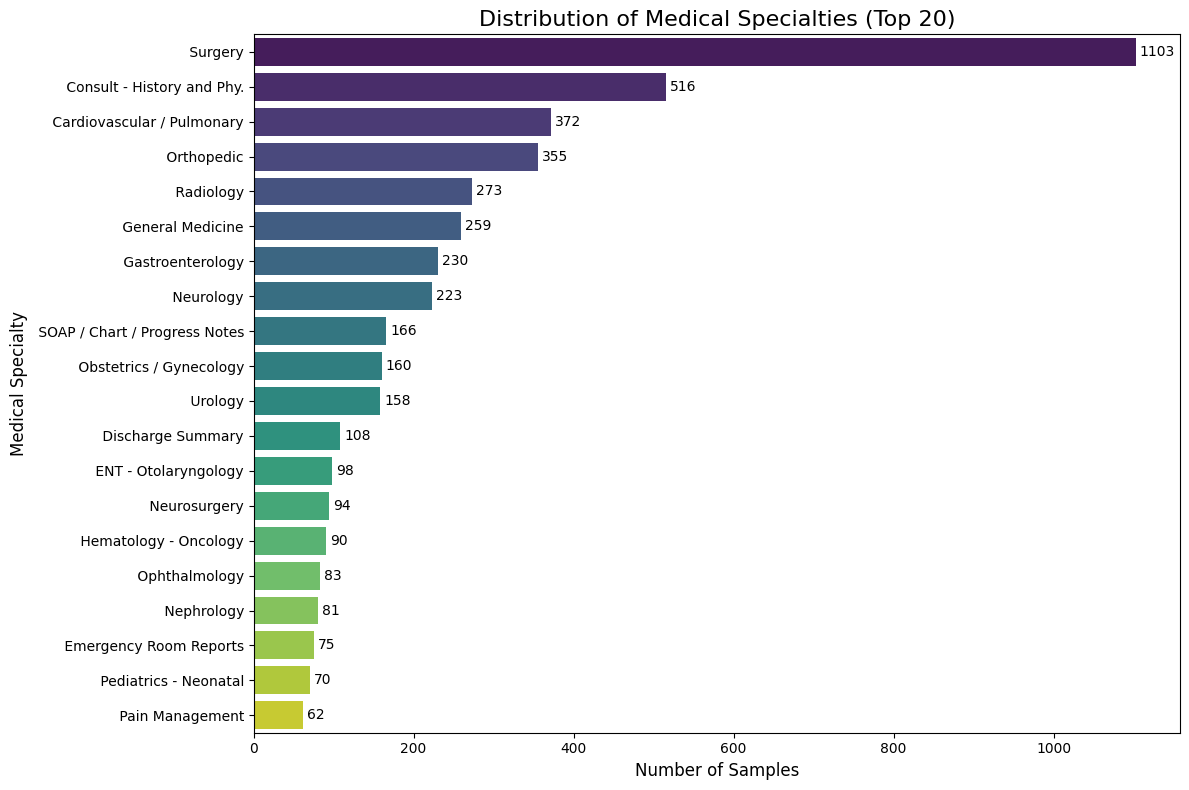

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
top20 = data_count_df.head(20)

sns.barplot(x='Data Count', y='Medical Specialty', data=top20,
            palette='viridis', hue='Medical Specialty', legend=False, ax=ax)

ax.set_title('Distribution of Medical Specialties (Top 20)', fontsize=16)
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_ylabel('Medical Specialty', fontsize=12)

# Use enumerate to get proper bar positions (0, 1, 2, ...)
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['Data Count'] + 5, i, str(row['Data Count']),
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Check for missing values across all columns
df.isna().sum()

In [ ]:
# Drop rows with missing transcriptions (33 rows)
df.dropna(subset=['transcription'], inplace=True)
# Strip leading/trailing whitespace from specialty names
df["medical_specialty"] = df["medical_specialty"].str.strip()

In [ ]:
# Keep only specialties with >= 60 samples
# This removes Office Notes (50) and Psychiatry (53)
# which have too few samples even after augmentation
min_samples =  60
counts = df["medical_specialty"].value_counts()
df = df[df["medical_specialty"].isin(counts[counts>= min_samples].index)]
df = df.reset_index(drop=True)
df.head()

In [ ]:
# Display class distribution before augmentation

import pandas as pd

medical_specialty_list = df['medical_specialty'].unique()
data_count_list =[]

for medical_specialty in medical_specialty_list:
    df_filter = df.loc[(df['medical_specialty'] == medical_specialty)]
    data_count_list.append(len(df_filter))

data_count_df = pd.DataFrame({'Medical Specialty':medical_specialty_list, 'Data Count':data_count_list})
data_count_df['Data Count'] = data_count_df['Data Count'].astype('int')
data_count_df = data_count_df.sort_values('Data Count', ascending=False)
data_count_df.reset_index(drop=True)

In [ ]:
# Text preprocessing pipeline:
# Input: raw transcription text
# Output: cleaned, lemmatized text stored in 'processed_data' column

import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

medical_stopwords = [
    'patient', 'history', 'diagnosis', 'procedure',
    'noted', 'reported', 'significant', 'normal',
    'negative', 'left', 'right', 'also', 'well',
    'given', 'used', 'placed', 'seen', 'found',
    'without', 'within', 'upon', 'using'
]

def data_preprocessing(data):
    data = data.lower()
    data = re.sub(r"[^a-z\s]", " ", data)
    tokens = data.split()

    # Combined stopwords
    all_stopwords = set(stopwords.words('english') + medical_stopwords)
    tokens = [t for t in tokens if t not in all_stopwords]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]

    return " ".join(tokens)

df['processed_data'] = df['transcription'].apply(data_preprocessing)
print("Done! Sample output:")
print(df['processed_data'].iloc[0][:200])

In [ ]:
# Verify processed_data column was added correctly
df.head()

In [ ]:
# Install deep-translator
!pip install deep-translator

In [ ]:
from deep_translator import GoogleTranslator
import time

def back_translate(text, mid_lang='fr'):
    try:
        # Truncate to 4000 chars (API limit)
        text = text[:4000]

        # English -> French -> English
        translated = GoogleTranslator(
            source='en',
            target=mid_lang
        ).translate(text)

        back = GoogleTranslator(
            source=mid_lang,
            target='en'
        ).translate(translated)

        # Small delay to avoid rate limiting
        time.sleep(0.5)

        return back
    except Exception as e:
        print(f"Translation failed: {e}")
        return text  # return original if fails

# Testing with one sample
sample = df['transcription'].iloc[0][:200]
print("Original:")
print(sample)
print("\nBack translated:")
print(back_translate(sample))

In [ ]:
# Augmentation Strategy:
# CAP (>=500)      -> undersample to 500 (majority classes)
# DOUBLE (100-499) -> keep original + generate back-translated copy
# TRIPLE (61-99)   -> keep original + generate 2 back-translated copies
# Back translation: English -> French -> English
# Preserves medical meaning better than synonym replacement

import pandas as pd

# strategy thresholds
CAP = 500          # undersample above this
DOUBLE_MIN = 100   # double between 100-499
TRIPLE_MIN = 61    # triple between 61-99

augmented_rows = []

counts = df['medical_specialty'].value_counts()

for specialty, count in counts.items():
    specialty_df = df[df['medical_specialty'] == specialty].copy()

    if count >= CAP:
        # Undersample to 500
        specialty_df = specialty_df.sample(n=CAP, random_state=42)
        augmented_rows.append(specialty_df)
        print(f"   {specialty}: {count} -> {CAP}")

    elif count >= DOUBLE_MIN:
        # Keep original & generate count new samples
        augmented_rows.append(specialty_df)
        new_samples = []
        samples_needed = count  # double = add same amount again

        for i in range(samples_needed):
            row = specialty_df.iloc[i % len(specialty_df)].copy()
            row['transcription'] = back_translate(row['transcription'])
            row['processed_data'] = data_preprocessing(row['transcription'])
            new_samples.append(row)

        augmented_rows.append(pd.DataFrame(new_samples))
        print(f"   {specialty}: {count} -> {count * 2}")

    else:
        # Keep original & generate 2x new samples (triple total)
        augmented_rows.append(specialty_df)
        new_samples = []
        samples_needed = count * 2  # triple = add 2x more

        for i in range(samples_needed):
            row = specialty_df.iloc[i % len(specialty_df)].copy()
            row['transcription'] = back_translate(row['transcription'])
            row['processed_data'] = data_preprocessing(row['transcription'])
            new_samples.append(row)

        augmented_rows.append(pd.DataFrame(new_samples))
        print(f"   {specialty}: {count} -> {count * 3}")

# Combine everything
df_augmented = pd.concat(augmented_rows, ignore_index=True)
print(f"\n  Final dataset size: {len(df_augmented)} rows")
print(f"  Specialties: {df_augmented['medical_specialty'].nunique()}")

df_augmented.to_csv('mtsamples_augmented.csv', index=False)
print("  Saved to mtsamples_augmented.csv")

In [ ]:
# Note: If running this cell independently after a session restart,
# uncomment the line below to reload the augmented dataset:
# df_augmented = pd.read_csv('mtsamples_augmented.csv')

print(f"Loaded {len(df_augmented)} rows")
print(f"Specialties: {df_augmented['medical_specialty'].nunique()}")

# These 5 specialties are document-type categories rather than
# clinical specialties, they showed poor recall during evaluation
# as their transcriptions overlap with actual medical specialties
specialties_to_remove = [
    'Surgery',
    'Consult - History and Phy.',
    'Radiology',
    'SOAP / Chart / Progress Notes',
    'Discharge Summary'
]

df_final = df_augmented[
    ~df_augmented['medical_specialty'].isin(specialties_to_remove)
].copy()

# Reset index
df_final = df_final.reset_index(drop=True)

# Re-encode labels 0-14 since we removed 5 classes
from sklearn.preprocessing import LabelEncoder
label_encoder_final = LabelEncoder()
df_final['label'] = label_encoder_final.fit_transform(
    df_final['medical_specialty']
)

# Print mapping so teammates know what each number means
print("Label mapping (0-14):")
for i, cls in enumerate(label_encoder_final.classes_):
    print(f"  {i}: {cls}")

print(f"\nRemoved {len(df_augmented) - len(df_final)} rows")
print(f"Remaining specialties: {df_final['medical_specialty'].nunique()}")
print(f"Total rows: {len(df_final)}")
print(f"\nFinal distribution:")
print(df_final['medical_specialty'].value_counts())

# Save final CSV
df_final.to_csv('augmented_mtsamples.csv', index=False)
print("\nSaved to augmented_mtsamples.csv")

In [26]:
import pandas as pd

df = pd.read_csv('augmented_mtsamples.csv')

In [27]:
medical_specialty_list = df['medical_specialty'].unique()
data_count_list =[]

for medical_specialty in medical_specialty_list:
    df_filter = df.loc[(df['medical_specialty'] == medical_specialty)]
    data_count_list.append(len(df_filter))

data_count_df = pd.DataFrame({'Medical Specialty':medical_specialty_list, 'Data Count':data_count_list})
data_count_df['Data Count'] = data_count_df['Data Count'].astype('int')
data_count_df = data_count_df.sort_values('Data Count', ascending=False)
data_count_df.reset_index(drop=True)

,Medical Specialty,Data Count
0,Cardiovascular / Pulmonary,742
1,Orthopedic,710
2,General Medicine,518
3,Gastroenterology,448
4,Neurology,446
5,Urology,312
6,Obstetrics / Gynecology,310
7,ENT - Otolaryngology,288
8,Neurosurgery,282
9,Hematology - Oncology,270


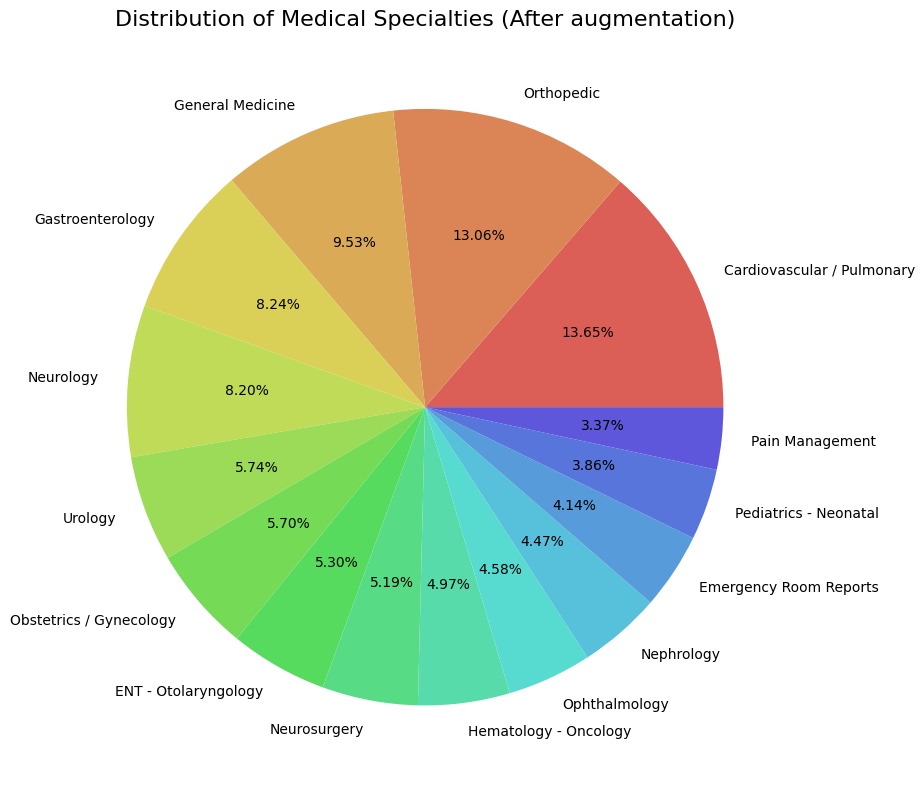

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 8))
# Generate a color palette from seaborn using 'hls' for a wider range of distinct colors
colors = sns.color_palette('hls', n_colors=len(df_combined))
ax.pie(data_count_df['Data Count'], labels=data_count_df['Medical Specialty'], autopct='%1.2f%%', colors=colors)

ax.set_title(f'Distribution of Medical Specialties (After augmentation)', fontsize=16)

plt.tight_layout()
plt.show()

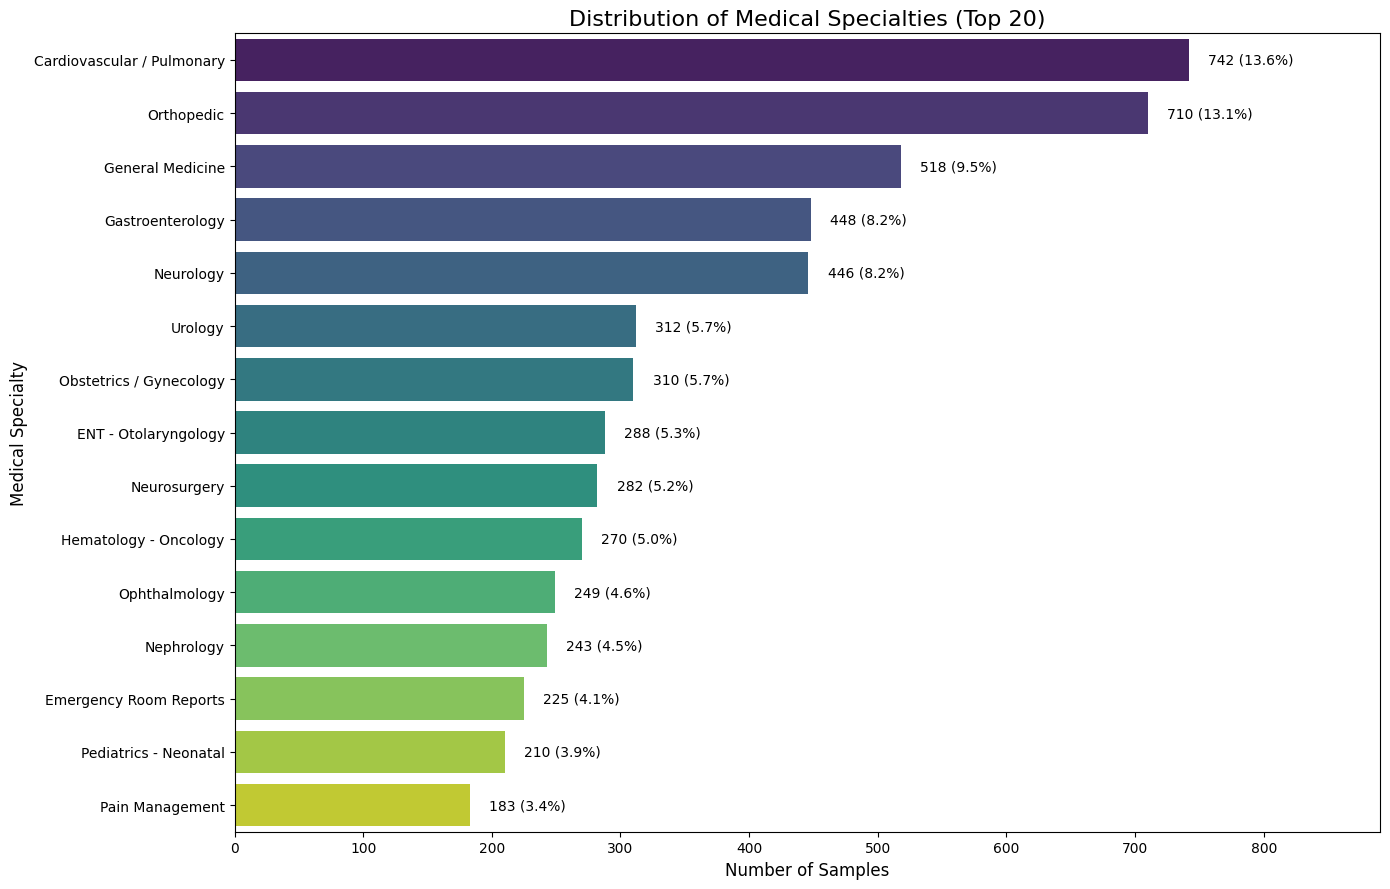

In [29]:
fig, ax = plt.subplots(figsize=(14, 9))
top20 = data_count_df.head(20).copy() # Ensure top20 is a copy

sns.barplot(x='Data Count', y='Medical Specialty', data=top20,
            palette='viridis', hue='Medical Specialty', legend=False, ax=ax)

ax.set_title('Distribution of Medical Specialties (Top 20)', fontsize=16)
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_ylabel('Medical Specialty', fontsize=12)

# Calculate percentages
total_count = top20['Data Count'].sum()
top20['Percentage'] = (top20['Data Count'] / total_count) * 100

# Use enumerate to get proper bar positions (0, 1, 2, ...)
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['Data Count'] + 15, i, f"{row['Data Count']} ({row['Percentage']:.1f}%)",
            va='center', fontsize=10)

# Adjust x-axis limits to prevent labels from being cut off
ax.set_xlim(right=top20['Data Count'].max() * 1.2)

plt.tight_layout()
plt.show()
